# MSigDB blitzgsea GSEA Saturation Plot (study subsampling)

**Environment:** `clamp-analyses`

Reads per-model CSV caches produced by `00_msigdb_blitzgsea_gsea_analysis_{clampfull,clampbase}.ipynb`
(capped K grid: 86/173/432 at rs_pct 1/5/10/25, seed 1 only) plus the shared 100% full-coverage anchor
(K=1728, cached once under `_blitzgsea_100pct_anchor/`, shared with the sibling saturation folder). Plots
MSigDB pathway coverage (FDR < 0.05 / FDR < 0.01) against K. Single seed per point — no PDF export, plots
displayed inline only.

In [1]:
library(here)
library(ggplot2)
library(dplyr)

input_dir  <- here("output/03_model_biology/00_archs4/08_saturation_study/blitzgsea_gsea")
anchor_dir <- here("output/03_model_biology/00_archs4/_blitzgsea_100pct_anchor")

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title        = element_text(size = 24, colour = "black"),
      axis.title.y      = element_text(margin = margin(r = 18)),
      axis.text         = element_text(size = 18, colour = "black"),
      axis.line         = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks        = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor   = element_blank(),
      legend.position    = "right",
      strip.background   = element_blank(),
      strip.text         = element_text(face = "bold", size = 18),
      plot.margin        = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load results: capped grid + shared 100% anchor

In [2]:
load_model_results <- function(model_type) {
  grid_files <- list.files(
    file.path(input_dir, model_type),
    pattern    = "^rs[0-9]+_k[0-9]+_seed1_msigdb_blitzgsea_gsea\\.csv$",
    full.names = TRUE
  )
  if (length(grid_files) == 0) {
    warning(sprintf("No grid CSVs found for %s", model_type))
    return(NULL)
  }

  rows <- lapply(grid_files, function(f) {
    m <- regmatches(basename(f), regexec("^rs([0-9]+)_k([0-9]+)_seed1_msigdb_blitzgsea_gsea\\.csv$", basename(f)))[[1]]
    if (length(m) < 3) return(NULL)
    df <- read.csv(f, check.names = FALSE)
    if (nrow(df) == 0) return(NULL)
    data.frame(
      rs_pct                = as.integer(m[2]),
      k_val                 = as.integer(m[3]),
      n_samples             = df$n_samples[1],
      n_total_msigdb        = df$n_total_msigdb[1],
      coverage_fdr05        = sum(df$min_fdr < 0.05) / df$n_total_msigdb[1],
      coverage_fdr01        = sum(df$min_fdr < 0.01) / df$n_total_msigdb[1],
      stringsAsFactors      = FALSE
    )
  })
  grid_df <- do.call(rbind, Filter(Negate(is.null), rows))

  # shared 100% anchor (same physical model for both saturation tracks)
  anchor_path <- file.path(anchor_dir, model_type, "anchor_msigdb_blitzgsea_gsea.csv")
  if (file.exists(anchor_path)) {
    adf <- read.csv(anchor_path, check.names = FALSE)
    anchor_row <- data.frame(
      rs_pct         = 100L,
      k_val          = adf$n_lvs[1],
      n_samples      = adf$n_samples[1],
      n_total_msigdb = adf$n_total_msigdb[1],
      coverage_fdr05 = sum(adf$min_fdr < 0.05) / adf$n_total_msigdb[1],
      coverage_fdr01 = sum(adf$min_fdr < 0.01) / adf$n_total_msigdb[1],
      stringsAsFactors = FALSE
    )
    grid_df <- rbind(grid_df, anchor_row)
  } else {
    warning("100% anchor not found yet: ", anchor_path)
  }

  grid_df[order(grid_df$rs_pct, grid_df$k_val), ]
}

results_full <- load_model_results("CLAMPfull")
results_base <- load_model_results("CLAMPbase")

message("CLAMPfull rows: ", if (!is.null(results_full)) nrow(results_full) else 0)
message("CLAMPbase rows: ", if (!is.null(results_base)) nrow(results_base) else 0)

CLAMPfull rows: 13



CLAMPbase rows: 13



## Prepare plot data

In [3]:
coverage_colors <- c(
  "1%"   = "#2166AC",
  "5%"   = "#4DAC26",
  "10%"  = "#D6604D",
  "25%"  = "#762A83",
  "100%" = "#000000"
)
coverage_shapes <- c("1%"=16, "5%"=3, "10%"=1, "25%"=17, "100%"=18)

make_plot_df <- function(df) {
  if (is.null(df)) return(NULL)
  df %>%
    dplyr::mutate(
      data_label         = factor(paste0(rs_pct, "%"), levels = paste0(c(1, 5, 10, 25, 100), "%")),
      coverage_fdr05_pct = coverage_fdr05 * 100,
      coverage_fdr01_pct = coverage_fdr01 * 100
    )
}

plot_full <- make_plot_df(results_full)
plot_base <- make_plot_df(results_base)

## Plot helper

In [4]:
make_sat_plot <- function(plot_df, y_col, y_label) {
  if (is.null(plot_df)) { message("No data, skipping plot"); return(invisible(NULL)) }
  ggplot(plot_df, aes(x = k_val, y = .data[[y_col]], colour = data_label)) +
    geom_line(aes(group = data_label), linewidth = 1.0) +
    geom_point(aes(shape = data_label), size = 3.0, stroke = 1.0) +
    scale_colour_manual(values = coverage_colors, name = "ARCHS4") +
    scale_shape_manual(values  = coverage_shapes, name = "ARCHS4") +
    scale_y_continuous(
      labels = scales::percent_format(accuracy = 0.1, scale = 1),
      limits = c(0, NA),
      expand = expansion(mult = c(0, 0.08))
    ) +
    labs(x = "K (number of LVs)", y = y_label) +
    theme_ng()
}

options(repr.plot.width = 10, repr.plot.height = 7)

## CLAMPfull: FDR 0.05

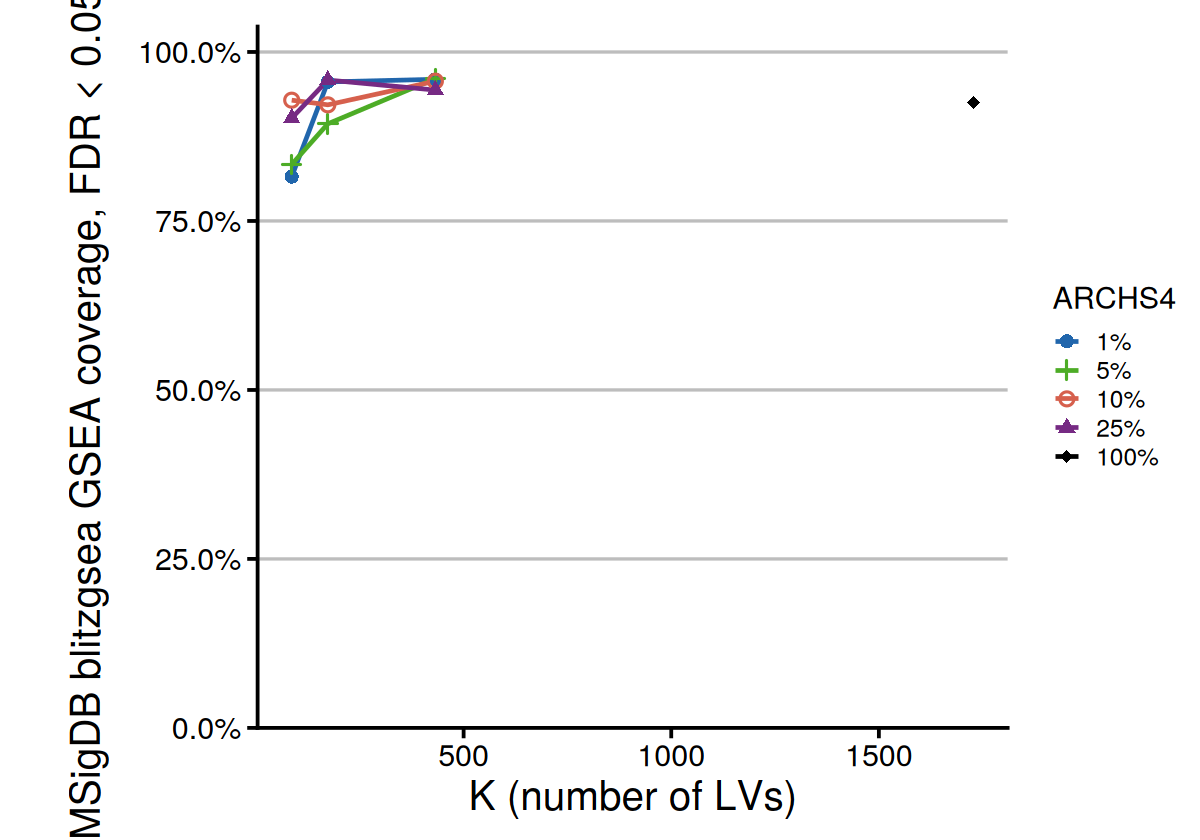

In [5]:
p_full_05 <- make_sat_plot(plot_full, "coverage_fdr05_pct", "MSigDB blitzgsea GSEA coverage, FDR < 0.05 (%)")
p_full_05

## CLAMPfull: FDR 0.01

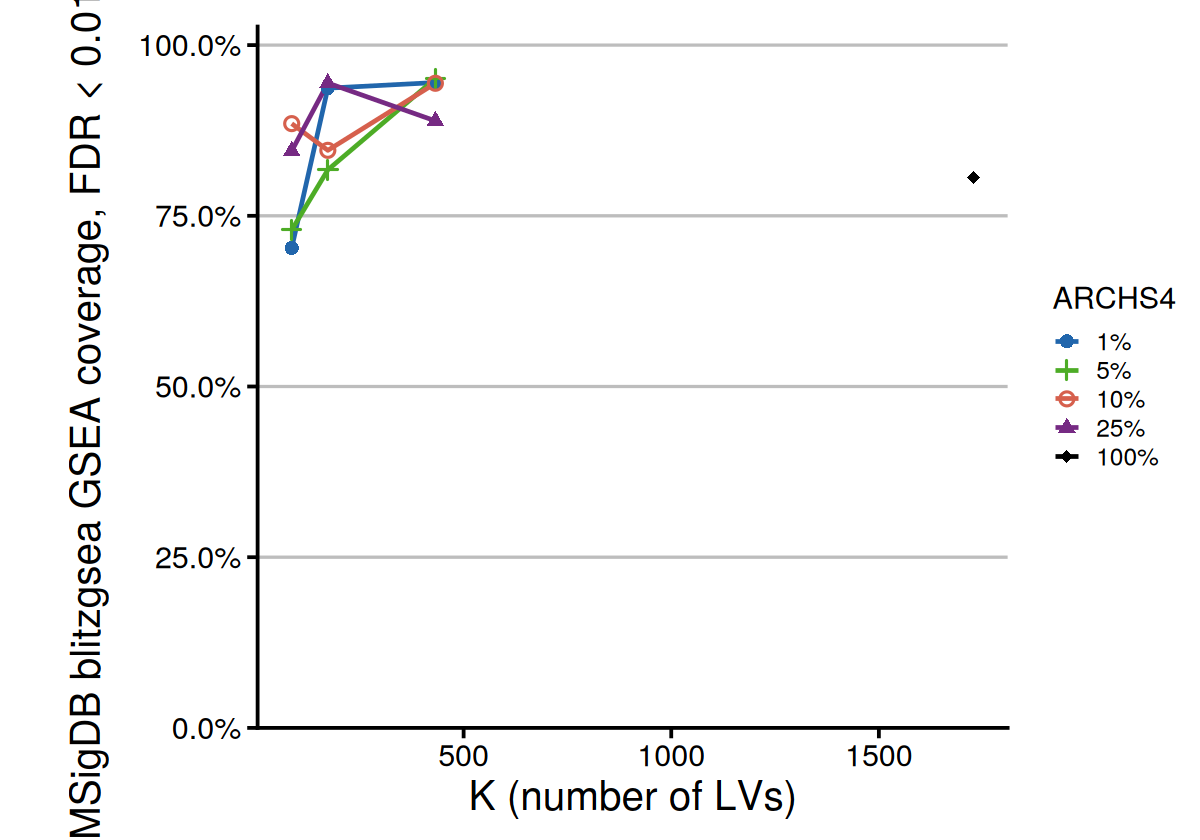

In [6]:
p_full_01 <- make_sat_plot(plot_full, "coverage_fdr01_pct", "MSigDB blitzgsea GSEA coverage, FDR < 0.01 (%)")
p_full_01

## CLAMPbase: FDR 0.05

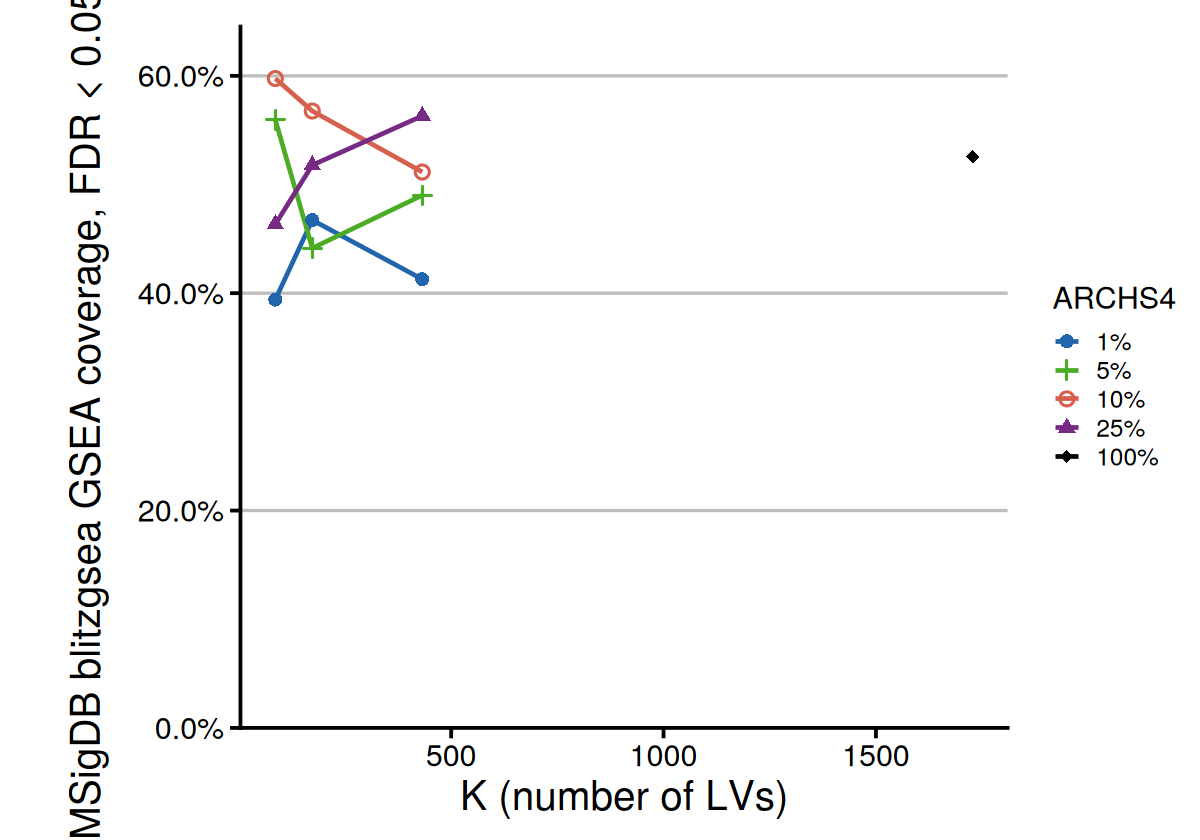

In [7]:
p_base_05 <- make_sat_plot(plot_base, "coverage_fdr05_pct", "MSigDB blitzgsea GSEA coverage, FDR < 0.05 (%)")
p_base_05

## CLAMPbase: FDR 0.01

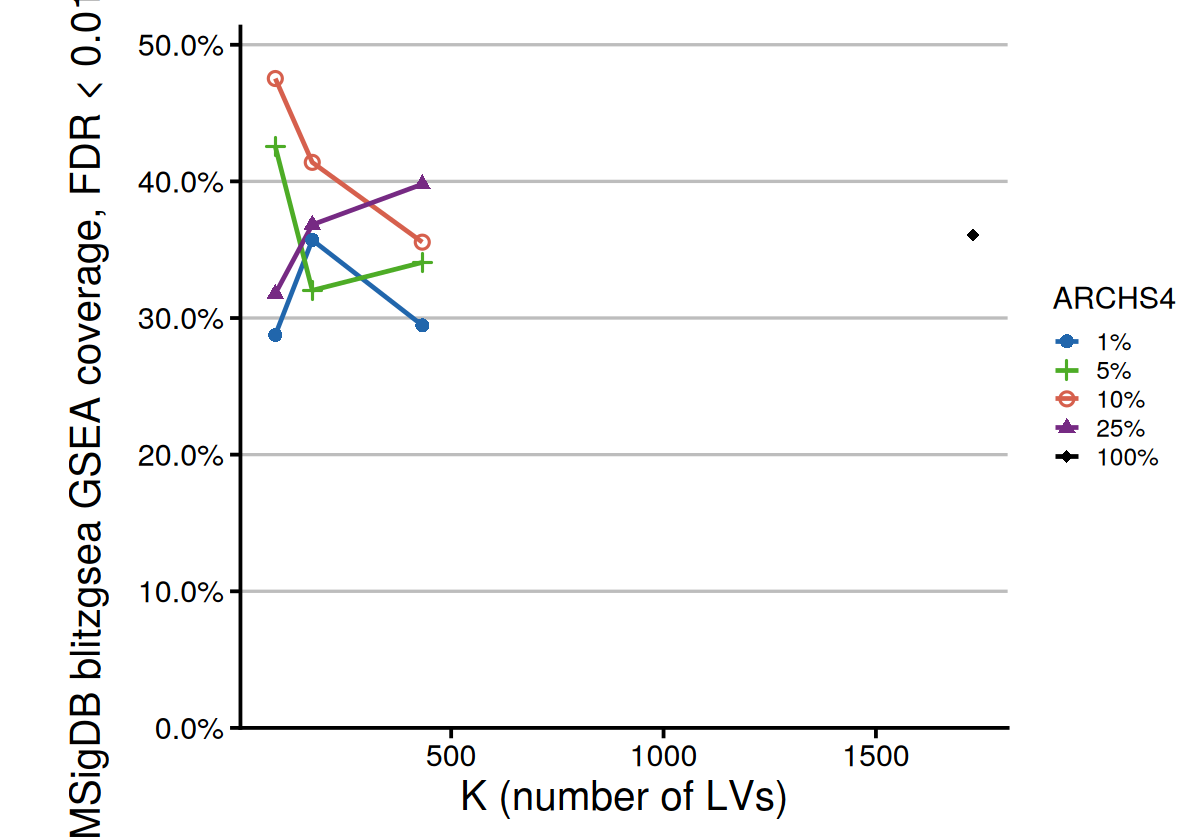

In [8]:
p_base_01 <- make_sat_plot(plot_base, "coverage_fdr01_pct", "MSigDB blitzgsea GSEA coverage, FDR < 0.01 (%)")
p_base_01